<a href="https://colab.research.google.com/github/kxrrym03/VALORANT-Champions-Tour-2025/blob/main/VALORANT_champions_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
upload = files.upload()

Saving vct2025_01_partnered_teams.csv to vct2025_01_partnered_teams.csv


In [ ]:
df = pd.read_csv('vct2025_01_partnered_teams.csv')
df.shape

(48, 6)

In [ ]:
df.head()

,team_name,region,league,country,team_type,league_location
0,NRG Esports,Americas,VCT Americas 2025,United States,Partner,"Los Angeles, USA"
1,Sentinels,Americas,VCT Americas 2025,United States,Partner,"Los Angeles, USA"
2,Cloud9,Americas,VCT Americas 2025,United States,Partner,"Los Angeles, USA"
3,100 Thieves,Americas,VCT Americas 2025,United States,Partner,"Los Angeles, USA"
4,LOUD,Americas,VCT Americas 2025,Brazil,Partner,"Los Angeles, USA"


In [ ]:

df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
team_name,0
region,0
league,0
country,0
team_type,0
league_location,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   team_name        48 non-null     object
 1   region           48 non-null     object
 2   league           48 non-null     object
 3   country          48 non-null     object
 4   team_type        48 non-null     object
 5   league_location  48 non-null     object
dtypes: object(6)
memory usage: 2.4+ KB


In [ ]:
df.describe()

,team_name,region,league,country,team_type,league_location
count,48,48,48,48,48,48
unique,48,4,4,20,4,4
top,NRG Esports,Americas,VCT Americas 2025,China,Partner,"Los Angeles, USA"
freq,1,12,12,12,40,12


In [ ]:
df.dtypes

,0
team_name,object
region,object
league,object
country,object
team_type,object
league_location,object


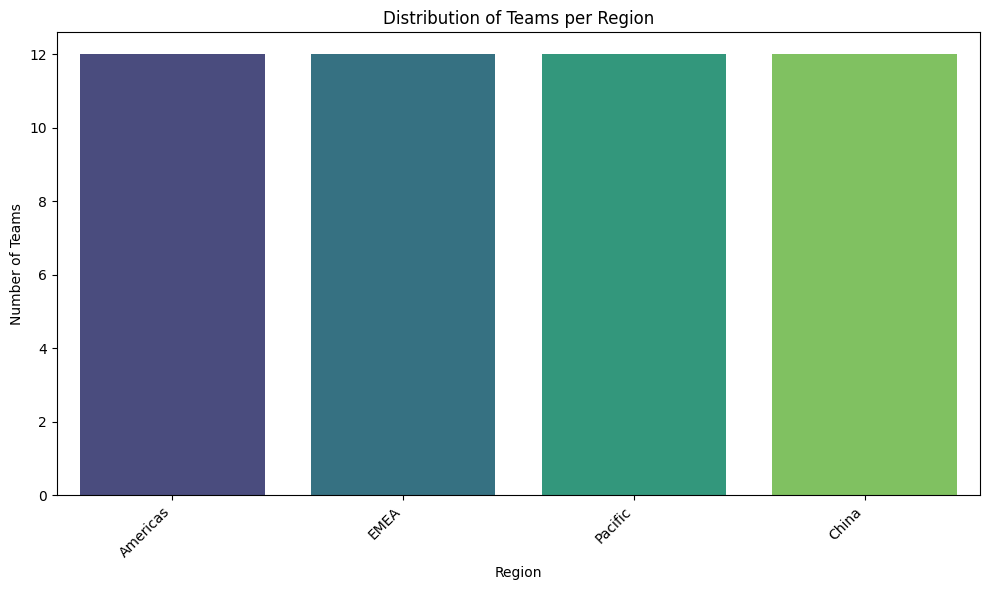

In [ ]:
region_counts = df['region'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette='viridis')
plt.title('Distribution of Teams per Region')
plt.xlabel('Region')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribution of Team Types

In [ ]:
team_type_counts = df['team_type'].value_counts()
display(team_type_counts)

,count
team_type,
Partner,40
Ascension 2024,4
Ascension 2023,3
Ascension 2024 Runner-up,1


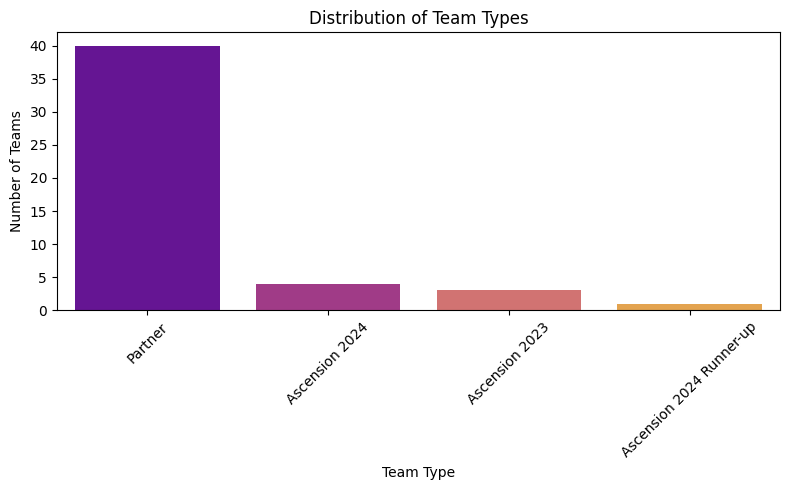

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=team_type_counts.index, y=team_type_counts.values, palette='plasma')
plt.title('Distribution of Team Types')
plt.xlabel('Team Type')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Teams by Country

In [ ]:
country_counts = df['country'].value_counts()
display(country_counts)

,count
country,
China,12
United States,6
South Korea,4
Brazil,3
Spain,3
France,3
Indonesia,2
Japan,2
Turkey,2


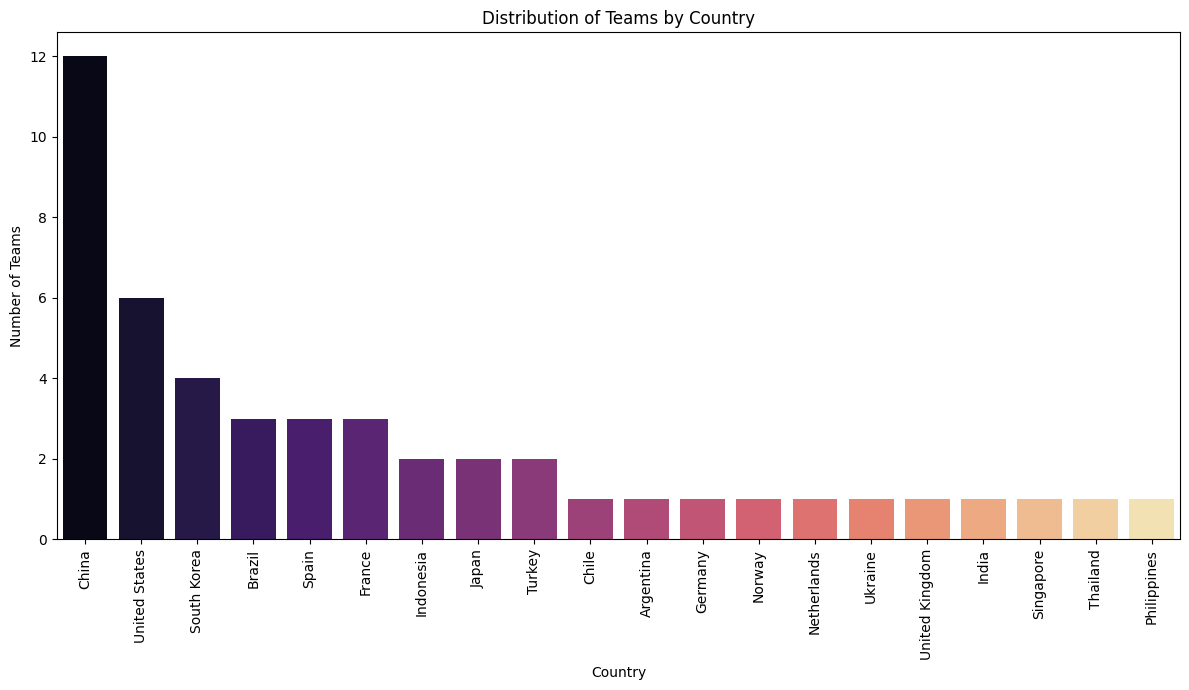

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='magma')
plt.title('Distribution of Teams by Country')
plt.xlabel('Country')
plt.ylabel('Number of Teams')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Distribution of Teams by League

In [ ]:
league_counts = df['league'].value_counts()
display(league_counts)

,count
league,
VCT Americas 2025,12
VCT EMEA 2025,12
VCT Pacific 2025,12
VCT China 2025,12


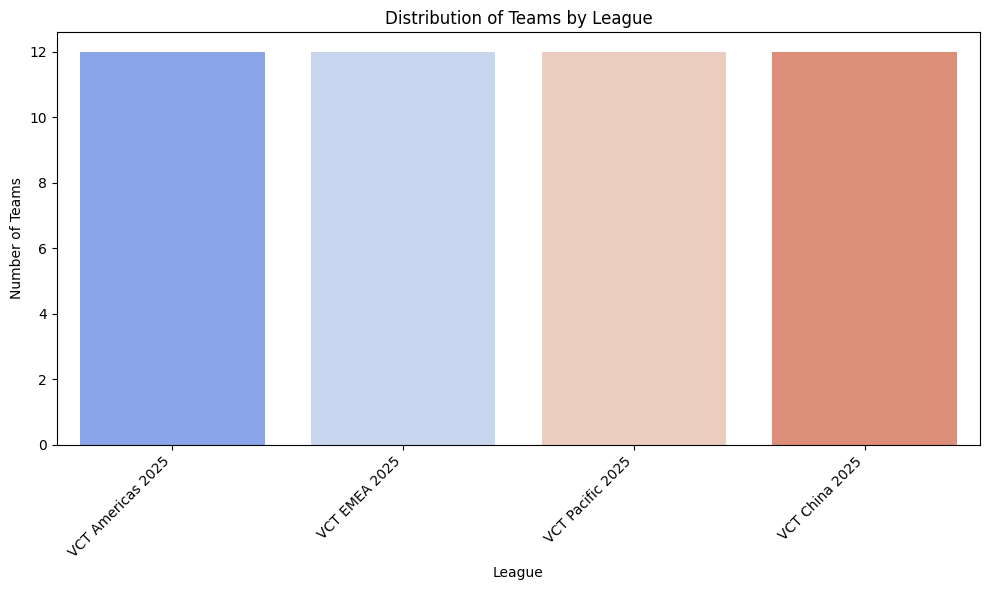

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=league_counts.index, y=league_counts.values, palette='coolwarm')
plt.title('Distribution of Teams by League')
plt.xlabel('League')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Cross-tabulation of Team Type and Region

In [ ]:
team_type_region_crosstab = pd.crosstab(df['region'], df['team_type'])
display(team_type_region_crosstab)

team_type,Ascension 2023,Ascension 2024,Ascension 2024 Runner-up,Partner
region,,,,
Americas,1,1,0,10
China,1,1,0,10
EMEA,1,1,0,10
Pacific,0,1,1,10


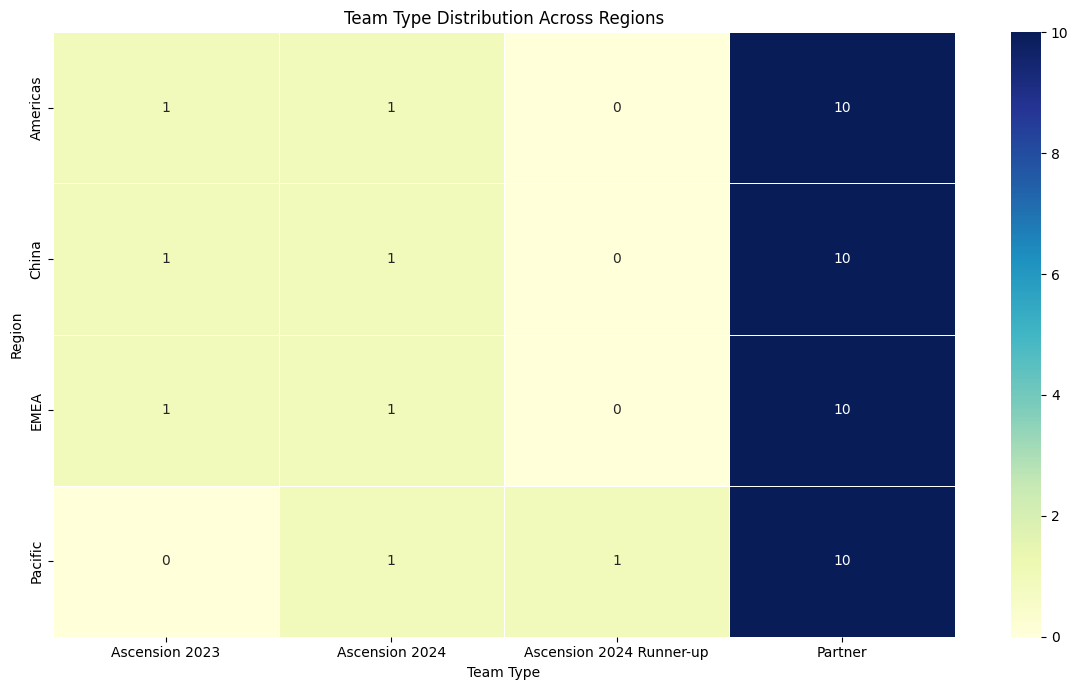

In [ ]:
plt.figure(figsize=(12, 7))
sns.heatmap(team_type_region_crosstab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Team Type Distribution Across Regions')
plt.xlabel('Team Type')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Distribution of Countries for 'Partner' Team Type

In [ ]:
partner_teams_df = df[df['team_type'] == 'Partner']
partner_country_counts = partner_teams_df['country'].value_counts()
display(partner_country_counts)

,count
country,
China,10
United States,5
Spain,3
South Korea,3
Brazil,2
Turkey,2
France,2
Japan,2
Chile,1


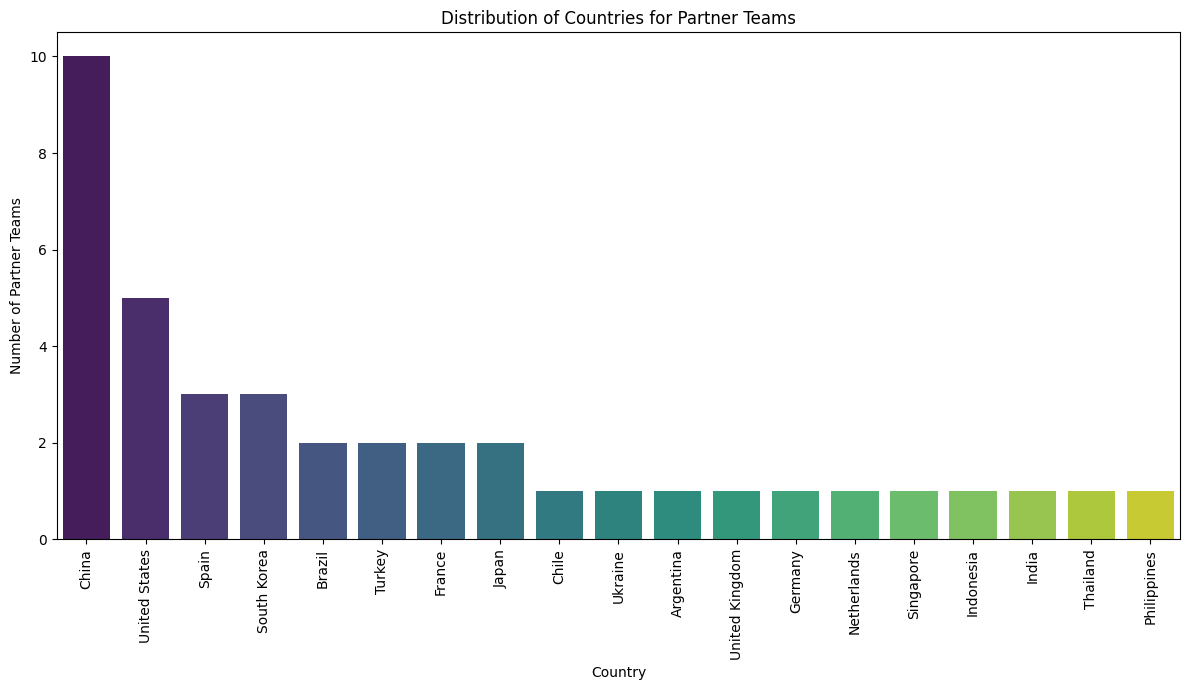

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=partner_country_counts.index, y=partner_country_counts.values, palette='viridis')
plt.title('Distribution of Countries for Partner Teams')
plt.xlabel('Country')
plt.ylabel('Number of Partner Teams')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Machine Learning Model Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

### Feature Engineering

In [ ]:
label_encoder = LabelEncoder()
df['region_encoded'] = label_encoder.fit_transform(df['region'])

# Display the mapping
print('Region mapping:')
for i, region in enumerate(label_encoder.classes_):
    print(f'{region}: {i}')

# Select features and target
X = df[['league', 'country', 'team_type', 'league_location']]
y = df['region_encoded']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['league', 'country', 'team_type', 'league_location'], drop_first=True)

print('\nShape of features (X):', X.shape)
print('Shape of target (y):', y.shape)
X.head()

Region mapping:
Americas: 0
China: 1
EMEA: 2
Pacific: 3

Shape of features (X): (48, 28)
Shape of target (y): (48,)


,league_VCT China 2025,league_VCT EMEA 2025,league_VCT Pacific 2025,country_Brazil,country_Chile,country_China,country_France,country_Germany,country_India,country_Indonesia,...,country_Turkey,country_Ukraine,country_United Kingdom,country_United States,team_type_Ascension 2024,team_type_Ascension 2024 Runner-up,team_type_Partner,"league_location_Los Angeles, USA","league_location_Seoul, South Korea","league_location_Shanghai, China"
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,True,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


### Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (38, 28)
X_test shape: (10, 28)
y_train shape: (38,)
y_test shape: (10,)


### Model Training

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('Model training complete!')

Model training complete!


### Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:\n', report)
print('\nConfusion Matrix:\n', conf_matrix)

Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Confusion Matrix:
 [[3 0 0 0]
 [0 2 0 0]
 [0 0 3 0]
 [0 0 0 2]]


### Confusion Matrix Visualization

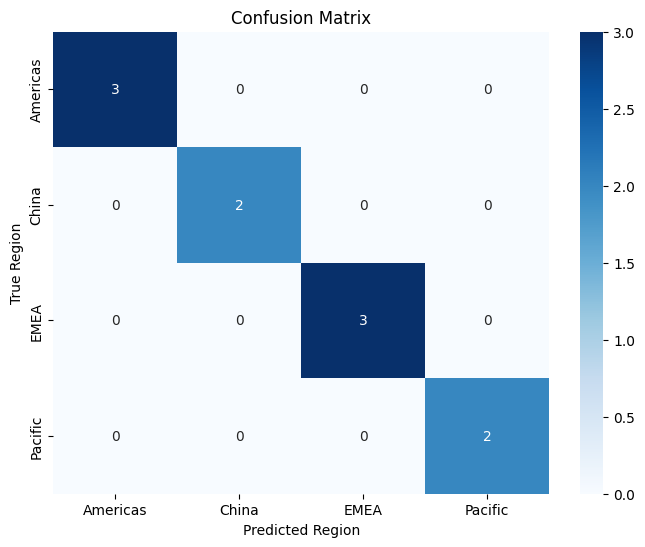

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Region')
plt.ylabel('True Region')
plt.show()

### Cross-Validation Score

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5) # Using 5-fold cross-validation

print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean():.4f}')
print(f'Standard deviation of cross-validation scores: {cv_scores.std():.4f}')

Cross-validation scores: [1. 1. 1. 1. 1.]
Mean cross-validation score: 1.0000
Standard deviation of cross-validation scores: 0.0000


### Feature Importance

In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
display(feature_importances)

,0
league_VCT EMEA 2025,0.152679
"league_location_Los Angeles, USA",0.140321
"league_location_Seoul, South Korea",0.138365
league_VCT China 2025,0.135586
league_VCT Pacific 2025,0.122360
"league_location_Shanghai, China",0.089940
country_China,0.081016
country_United States,0.041009
country_Spain,0.019471
country_Japan,0.010869


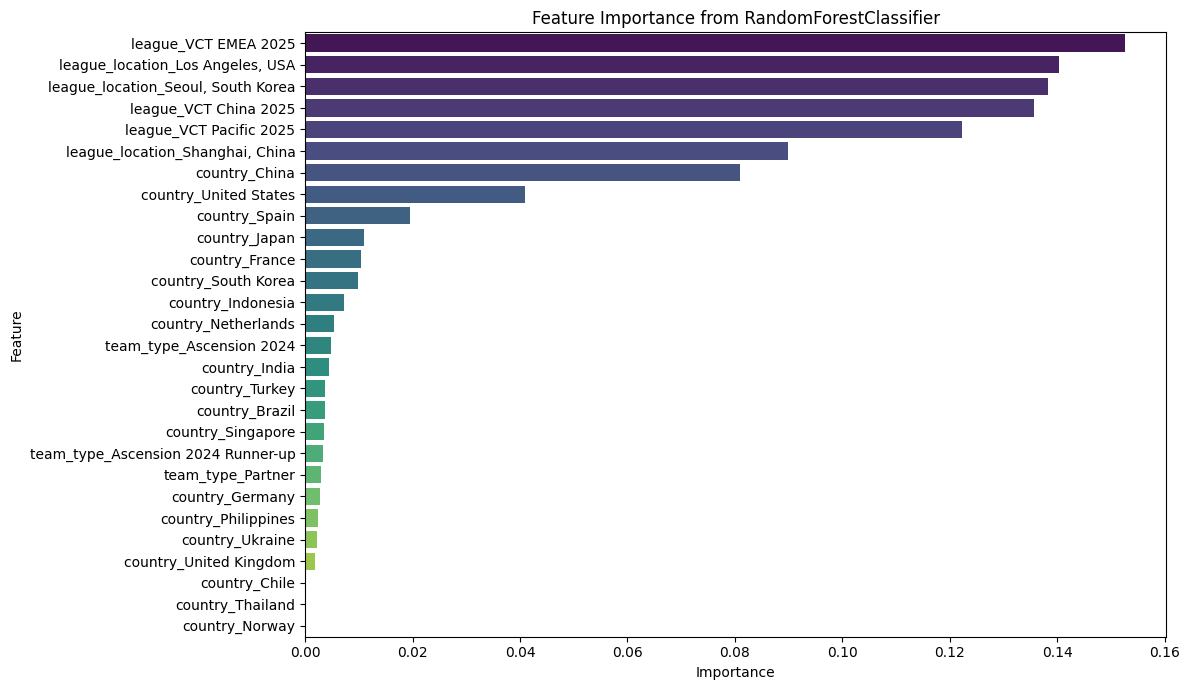

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()